<a href="https://colab.research.google.com/github/rodrigorissettoterra/ai-model-studies/blob/main/015_recommender_system_ranking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Sistemas de recomendação: prever afinidade não basta, é preciso ranquear

**Área:** Machine Learning / Recommender Systems  
**Tipo de problema:** Recomendação personalizada e ranking Top-K

### Pergunta de estudo

> Um modelo personalizado consegue colocar itens relevantes no topo da lista melhor do que um ranking global de popularidade, e quais trade-offs aparecem entre relevância, cobertura e diversidade?

O estudo simula interações de um e-commerce e compara quatro estratégias:

1. **Popularity baseline** — recomenda os itens mais populares globalmente;
2. **Content-based** — aprende preferências de categoria a partir do histórico do usuário;
3. **Collaborative Filtering** — aprende fatores latentes a partir da matriz usuário-item;
4. **Hybrid Ranking** — combina sinais colaborativos, de conteúdo e popularidade.

### Métricas

#### Relevância Top-K
- Precision@K;
- Recall@K;
- MAP@K;
- NDCG@K;
- Hit Rate@K.

#### Saúde do catálogo
- Catalog Coverage;
- Category Diversity.

### Princípios do estudo

- split temporal por usuário;
- treino apenas com interações passadas;
- itens já vistos são excluídos da recomendação;
- teste permanece invisível aos modelos;
- avaliação é feita sobre **ranking**, não apenas erro de predição.

> Um sistema de recomendação útil precisa responder não apenas **“qual item tem maior score?”**, mas **“os itens relevantes aparecem cedo na lista e o sistema explora o catálogo de forma saudável?”**


## 1. Importações e reprodutibilidade

O notebook é autocontido e utiliza bibliotecas disponíveis no Google Colab.


In [ ]:
import math
import platform
import random
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import sklearn

from scipy.sparse import csr_matrix
from sklearn.decomposition import TruncatedSVD

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
rng = np.random.default_rng(SEED)

print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("SciPy:", scipy.__version__)
print("scikit-learn:", sklearn.__version__)


Python: 3.12.13
Platform: Linux-6.6.122+-x86_64-with-glibc2.35
NumPy: 2.0.2
Pandas: 2.2.2
SciPy: 1.16.3
scikit-learn: 1.6.1


## 2. Geração de um ambiente de e-commerce

Os dados são simulados para que:

- cada item pertença a uma categoria;
- alguns itens sejam naturalmente mais populares;
- usuários tenham preferências diferentes entre categorias;
- interações sejam geradas a partir da combinação entre afinidade e popularidade.

As preferências latentes usadas para gerar os dados **não serão fornecidas aos modelos**.

Isso permite criar um ground truth controlado sem depender de downloads externos.


In [ ]:
N_USERS = 600
N_ITEMS = 320
N_CATEGORIES = 8
INTERACTIONS_PER_USER = 40
TEST_ITEMS_PER_USER = 5
TOP_K = 10

categories = np.array([
    "electronics",
    "home",
    "books",
    "sports",
    "beauty",
    "toys",
    "fashion",
    "grocery",
])

item_ids = np.arange(N_ITEMS)
item_category_id = rng.integers(
    0,
    N_CATEGORIES,
    size=N_ITEMS,
)

# Popularidade de cauda longa.
raw_popularity = rng.lognormal(
    mean=0.0,
    sigma=1.0,
    size=N_ITEMS,
)
item_popularity_prior = (
    raw_popularity / raw_popularity.sum()
)

catalog = pd.DataFrame({
    "item_id": item_ids,
    "category": categories[item_category_id],
    "popularity_prior": item_popularity_prior,
})

# Perfis latentes de categoria por usuário.
user_category_preferences = rng.dirichlet(
    alpha=np.full(N_CATEGORIES, 0.45),
    size=N_USERS,
)

rows = []
timestamp = 0

for user_id in range(N_USERS):
    affinity = user_category_preferences[
        user_id,
        item_category_id,
    ]

    score = (
        0.80 * affinity
        + 0.20 * (
            item_popularity_prior
            / item_popularity_prior.max()
        )
    )

    score = np.maximum(score, 1e-12)
    probability = score / score.sum()

    chosen = rng.choice(
        item_ids,
        size=INTERACTIONS_PER_USER,
        replace=False,
        p=probability,
    )

    for position, item_id in enumerate(chosen):
        timestamp += 1
        rows.append({
            "user_id": user_id,
            "item_id": int(item_id),
            "timestamp": timestamp,
            "position": position,
        })

interactions = pd.DataFrame(rows).merge(
    catalog[["item_id", "category"]],
    on="item_id",
    how="left",
)

print(f"Usuários: {N_USERS:,}")
print(f"Itens: {N_ITEMS:,}")
print(f"Interações: {len(interactions):,}")
display(catalog.head())
display(interactions.head())


Usuários: 600
Itens: 320
Interações: 24,000


,item_id,category,popularity_prior
0,0,electronics,0.005051
1,1,fashion,0.001147
2,2,toys,0.000578
3,3,sports,0.000720
4,4,sports,0.000915


,user_id,item_id,timestamp,position,category
0,0,139,1,0,sports
1,0,21,2,1,books
2,0,275,3,2,sports
3,0,4,4,3,sports
4,0,283,5,4,sports


## 3. Split temporal por usuário

Para cada usuário:

- as primeiras interações formam o conjunto de treino;
- as últimas `5` interações formam o teste.

Esse desenho aproxima um cenário real: usamos o passado para tentar recomendar itens que o usuário escolherá depois.

O split aleatório de linhas poderia deixar interações futuras vazarem para o treino, produzindo uma avaliação otimista.


In [ ]:
cutoff = INTERACTIONS_PER_USER - TEST_ITEMS_PER_USER

train = interactions[
    interactions["position"] < cutoff
].copy()

test = interactions[
    interactions["position"] >= cutoff
].copy()

assert len(train) + len(test) == len(interactions)
assert train.groupby("user_id").size().eq(cutoff).all()
assert test.groupby("user_id").size().eq(TEST_ITEMS_PER_USER).all()

train_pairs = set(
    zip(train["user_id"], train["item_id"])
)
test_pairs = set(
    zip(test["user_id"], test["item_id"])
)

assert train_pairs.isdisjoint(test_pairs)

print(f"Treino: {len(train):,} interações")
print(f"Teste: {len(test):,} interações")
print("Leakage usuário-item entre treino e teste: NÃO")


Treino: 21,000 interações
Teste: 3,000 interações
Leakage usuário-item entre treino e teste: NÃO


## 4. Matriz usuário-item

As interações são implícitas: `1` significa que o usuário interagiu com o item.

A matriz será construída **somente com o conjunto de treino**.


In [ ]:
user_item = np.zeros(
    (N_USERS, N_ITEMS),
    dtype=np.float32,
)

user_item[
    train["user_id"].to_numpy(),
    train["item_id"].to_numpy(),
] = 1.0

sparse_user_item = csr_matrix(user_item)

density = user_item.mean()

print("Shape:", user_item.shape)
print(f"Densidade: {density:.2%}")


Shape: (600, 320)
Densidade: 10.94%


# Parte A — Modelos de recomendação


## 5. Baseline de popularidade

O baseline recomenda os itens mais consumidos no treino.

Ele é simples, barato e frequentemente competitivo, mas não é personalizado.


In [ ]:
item_train_counts = np.asarray(
    sparse_user_item.sum(axis=0)
).ravel()

popularity_scores = (
    item_train_counts
    / max(item_train_counts.max(), 1)
)

popularity_matrix = np.tile(
    popularity_scores,
    (N_USERS, 1),
)

print("Top 10 itens mais populares no treino:")
display(
    pd.DataFrame({
        "item_id": np.argsort(
            -popularity_scores
        )[:10],
    }).merge(
        catalog,
        on="item_id",
        how="left",
    )
)


Top 10 itens mais populares no treino:


,item_id,category,popularity_prior
0,91,fashion,0.034531
1,69,sports,0.023436
2,5,fashion,0.015883
3,218,sports,0.019384
4,70,fashion,0.012350
5,116,electronics,0.015332
6,295,beauty,0.013301
7,296,fashion,0.015086
8,152,grocery,0.010688
9,33,beauty,0.010596


## 6. Modelo content-based

Para cada usuário, estimamos sua preferência por categoria usando apenas as interações de treino.

O score de um item combina:

- afinidade do usuário com a categoria;
- um pequeno sinal de popularidade para desempate.

Esse modelo consegue personalizar mesmo sem aprender relações complexas entre usuários.


In [ ]:
train_with_category = train.merge(
    catalog[["item_id", "category"]],
    on="item_id",
    how="left",
    suffixes=("", "_catalog"),
)

category_index = {
    category: idx
    for idx, category in enumerate(categories)
}

user_category_counts = np.zeros(
    (N_USERS, N_CATEGORIES),
    dtype=np.float32,
)

for row in train_with_category.itertuples():
    cat = row.category
    user_category_counts[
        row.user_id,
        category_index[cat],
    ] += 1

user_category_affinity = (
    user_category_counts
    / np.maximum(
        user_category_counts.sum(
            axis=1,
            keepdims=True,
        ),
        1,
    )
)

content_scores = (
    user_category_affinity[:, item_category_id]
    * (0.85 + 0.15 * popularity_scores)
)

print("Matriz de scores content-based:", content_scores.shape)


Matriz de scores content-based: (600, 320)


## 7. Collaborative Filtering com fatores latentes

Aplicaremos `TruncatedSVD` na matriz usuário-item.

A decomposição aprende dimensões latentes que podem capturar padrões de coocorrência:

\[
R \approx U\Sigma V^T
\]

O modelo não recebe categorias nem as preferências latentes usadas na simulação.


In [ ]:
N_COMPONENTS = 32

svd = TruncatedSVD(
    n_components=N_COMPONENTS,
    random_state=SEED,
)

user_factors = svd.fit_transform(
    sparse_user_item,
)

cf_scores = user_factors @ svd.components_

print("User factors:", user_factors.shape)
print("Item factors:", svd.components_.shape)
print(
    "Variância explicada acumulada:",
    f"{svd.explained_variance_ratio_.sum():.2%}",
)


User factors: (600, 32)
Item factors: (32, 320)
Variância explicada acumulada: 31.57%


## 8. Ranking híbrido

Sistemas reais frequentemente combinam múltiplos sinais.

Aqui combinaremos:

- `70%` collaborative filtering;
- `20%` content-based;
- `10%` popularidade.

Antes da combinação, normalizamos os scores por usuário para uma escala comum.


In [ ]:
def row_minmax(matrix):
    row_min = matrix.min(axis=1, keepdims=True)
    row_max = matrix.max(axis=1, keepdims=True)
    denominator = np.maximum(
        row_max - row_min,
        1e-12,
    )
    return (matrix - row_min) / denominator

cf_norm = row_minmax(cf_scores)
content_norm = row_minmax(content_scores)
pop_norm = popularity_matrix

hybrid_scores = (
    0.70 * cf_norm
    + 0.20 * content_norm
    + 0.10 * pop_norm
)

print("Matriz híbrida:", hybrid_scores.shape)


Matriz híbrida: (600, 320)


# Parte B — Avaliação de ranking


## 9. Função Top-K sem itens já vistos

Uma recomendação offline válida deve impedir que itens usados no treino sejam recomendados novamente, salvo quando repetição fizer parte do produto.

Neste estudo, o objetivo é descoberta de novos itens.


In [ ]:
seen_mask = user_item.astype(bool)

def top_k_recommendations(
    score_matrix,
    k=10,
):
    scores = score_matrix.copy()
    scores[seen_mask] = -np.inf

    candidate_idx = np.argpartition(
        -scores,
        kth=k - 1,
        axis=1,
    )[:, :k]

    candidate_scores = np.take_along_axis(
        scores,
        candidate_idx,
        axis=1,
    )

    order = np.argsort(
        -candidate_scores,
        axis=1,
    )

    ranked = np.take_along_axis(
        candidate_idx,
        order,
        axis=1,
    )

    return ranked

recommendations = {
    "Popularity": top_k_recommendations(
        popularity_matrix,
        TOP_K,
    ),
    "Content-based": top_k_recommendations(
        content_scores,
        TOP_K,
    ),
    "Collaborative Filtering": top_k_recommendations(
        cf_scores,
        TOP_K,
    ),
    "Hybrid": top_k_recommendations(
        hybrid_scores,
        TOP_K,
    ),
}

for name, recs in recommendations.items():
    assert recs.shape == (N_USERS, TOP_K)
    assert not np.any(
        np.take_along_axis(
            seen_mask,
            recs,
            axis=1,
        )
    )

print("Todos os modelos excluem itens vistos no treino.")


Todos os modelos excluem itens vistos no treino.


## 10. Precision@K, Recall@K, MAP@K, NDCG@K e Hit Rate@K

Para cada usuário, o conjunto relevante é formado pelos itens do teste.

As métricas respondem perguntas diferentes:

- **Precision@K:** qual fração da lista recomendada é relevante?
- **Recall@K:** quanto dos itens relevantes conseguimos recuperar?
- **MAP@K:** os acertos aparecem cedo de forma consistente?
- **NDCG@K:** itens relevantes recebem maior crédito quando aparecem no topo?
- **Hit Rate@K:** pelo menos um item relevante apareceu?


In [ ]:
test_truth = {
    user_id: set(group["item_id"])
    for user_id, group in test.groupby("user_id")
}

def average_precision_at_k(
    recommended,
    relevant,
    k,
):
    hits = 0
    precision_sum = 0.0

    for rank, item_id in enumerate(
        recommended[:k],
        start=1,
    ):
        if item_id in relevant:
            hits += 1
            precision_sum += hits / rank

    denominator = min(
        len(relevant),
        k,
    )

    return (
        precision_sum / denominator
        if denominator > 0
        else 0.0
    )

def ndcg_at_k(
    recommended,
    relevant,
    k,
):
    dcg = 0.0

    for rank, item_id in enumerate(
        recommended[:k],
        start=1,
    ):
        if item_id in relevant:
            dcg += 1 / math.log2(rank + 1)

    ideal_hits = min(
        len(relevant),
        k,
    )

    idcg = sum(
        1 / math.log2(rank + 1)
        for rank in range(1, ideal_hits + 1)
    )

    return dcg / idcg if idcg > 0 else 0.0

def evaluate_ranking(
    ranked_items,
    k=10,
):
    precision_values = []
    recall_values = []
    map_values = []
    ndcg_values = []
    hit_values = []
    category_diversity = []

    unique_recommended = set()

    for user_id in range(N_USERS):
        recommended = list(
            ranked_items[user_id, :k]
        )

        relevant = test_truth[user_id]

        hits = sum(
            item_id in relevant
            for item_id in recommended
        )

        precision_values.append(
            hits / k
        )

        recall_values.append(
            hits / len(relevant)
        )

        map_values.append(
            average_precision_at_k(
                recommended,
                relevant,
                k,
            )
        )

        ndcg_values.append(
            ndcg_at_k(
                recommended,
                relevant,
                k,
            )
        )

        hit_values.append(
            float(hits > 0)
        )

        unique_recommended.update(
            recommended
        )

        rec_categories = set(
            item_category_id[recommended]
        )

        category_diversity.append(
            len(rec_categories)
            / min(k, N_CATEGORIES)
        )

    return {
        f"Precision@{k}": np.mean(
            precision_values
        ),
        f"Recall@{k}": np.mean(
            recall_values
        ),
        f"MAP@{k}": np.mean(
            map_values
        ),
        f"NDCG@{k}": np.mean(
            ndcg_values
        ),
        f"HitRate@{k}": np.mean(
            hit_values
        ),
        "CatalogCoverage": (
            len(unique_recommended)
            / N_ITEMS
        ),
        "CategoryDiversity": np.mean(
            category_diversity
        ),
    }

evaluation_rows = []

for name, recs in recommendations.items():
    row = {
        "Model": name,
        **evaluate_ranking(
            recs,
            TOP_K,
        ),
    }
    evaluation_rows.append(row)

evaluation = pd.DataFrame(
    evaluation_rows
).set_index("Model")

display(
    evaluation.style.format(
        "{:.2%}"
    )
)


,Precision@10,Recall@10,MAP@10,NDCG@10,HitRate@10,CatalogCoverage,CategoryDiversity
Model,,,,,,,
Popularity,3.23%,6.47%,2.18%,5.19%,28.50%,5.62%,68.33%
Content-based,6.55%,13.10%,4.71%,10.43%,49.67%,65.00%,13.58%
Collaborative Filtering,5.12%,10.23%,3.63%,8.16%,39.67%,99.69%,42.06%
Hybrid,5.72%,11.43%,4.14%,9.19%,43.83%,99.38%,22.96%


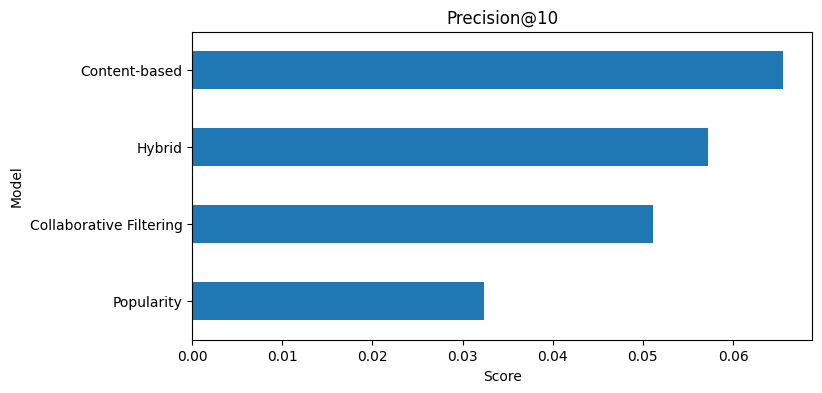

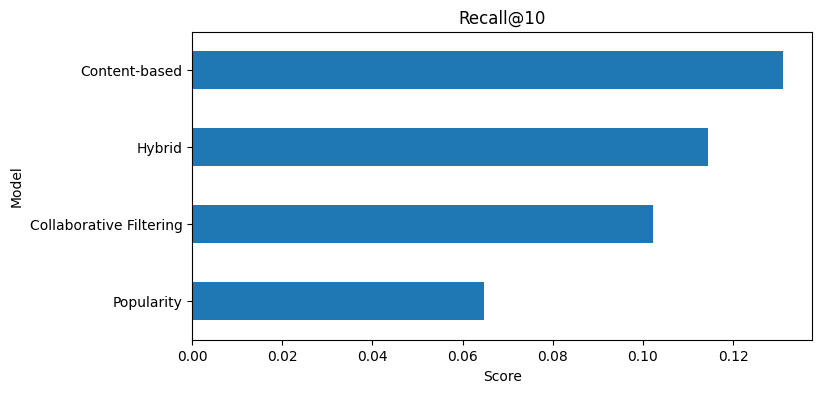

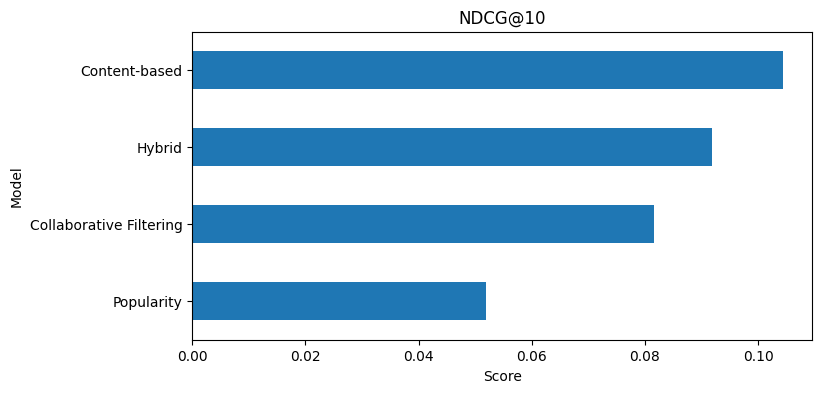

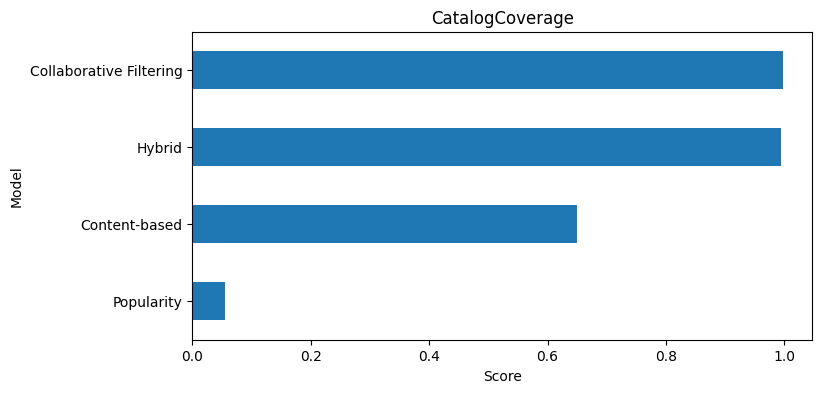

In [ ]:
plot_metrics = [
    f"Precision@{TOP_K}",
    f"Recall@{TOP_K}",
    f"NDCG@{TOP_K}",
    "CatalogCoverage",
]

for metric in plot_metrics:
    fig, ax = plt.subplots(figsize=(8, 4))
    evaluation[metric].sort_values().plot(
        kind="barh",
        ax=ax,
    )
    ax.set_title(metric)
    ax.set_xlabel("Score")
    plt.show()


## 11. Inspeção qualitativa de um usuário

Métricas agregadas são essenciais, mas também é útil inspecionar algumas listas.

A seguir veremos:

- histórico do usuário;
- itens relevantes no teste;
- Top-10 recomendado por cada modelo.


In [ ]:
SAMPLE_USER = 7

def user_items_table(
    item_list,
    label,
):
    return (
        pd.DataFrame({
            "item_id": list(item_list),
        })
        .merge(
            catalog,
            on="item_id",
            how="left",
        )
        .assign(source=label)
    )

history_items = train.loc[
    train["user_id"] == SAMPLE_USER,
    "item_id",
].tolist()

test_items = test.loc[
    test["user_id"] == SAMPLE_USER,
    "item_id",
].tolist()

print("Categorias mais frequentes no histórico:")
display(
    train.loc[
        train["user_id"] == SAMPLE_USER,
        "category",
    ]
    .value_counts()
    .to_frame("train_count")
)

print("Itens relevantes no teste:")
display(
    user_items_table(
        test_items,
        "test",
    )
)

for name, recs in recommendations.items():
    print(f"Top-{TOP_K} — {name}")
    display(
        user_items_table(
            recs[SAMPLE_USER],
            name,
        )
    )


Categorias mais frequentes no histórico:


,train_count
category,
fashion,13
books,7
home,6
toys,4
sports,3
beauty,1
grocery,1


Itens relevantes no teste:


,item_id,category,popularity_prior,source
0,1,fashion,0.001147,test
1,107,toys,0.003029,test
2,244,toys,0.002302,test
3,17,home,0.000527,test
4,21,books,0.001679,test


Top-10 — Popularity


...

,item_id,category,popularity_prior,source
0,91,fashion,0.034531,Content-based
1,36,fashion,0.008152,Content-based
2,209,fashion,0.000899,Content-based
3,150,fashion,0.006937,Content-based
4,231,fashion,0.002492,Content-based
5,260,fashion,0.007131,Content-based
6,301,fashion,0.002638,Content-based
7,277,fashion,0.004783,Content-based
8,111,fashion,0.001994,Content-based
9,37,fashion,0.000625,Content-based


Top-10 — Collaborative Filtering


,item_id,category,popularity_prior,source
0,209,fashion,0.000899,Collaborative Filtering
1,87,books,0.015896,Collaborative Filtering
2,233,fashion,0.000188,Collaborative Filtering
3,150,fashion,0.006937,Collaborative Filtering
4,173,toys,0.008568,Collaborative Filtering
5,262,books,0.007318,Collaborative Filtering
6,38,books,0.000773,Collaborative Filtering
7,1,fashion,0.001147,Collaborative Filtering
8,222,toys,0.001196,Collaborative Filtering
9,152,grocery,0.010688,Collaborative Filtering


Top-10 — Hybrid


,item_id,category,popularity_prior,source
0,209,fashion,0.000899,Hybrid
1,150,fashion,0.006937,Hybrid
2,233,fashion,0.000188,Hybrid
3,87,books,0.015896,Hybrid
4,1,fashion,0.001147,Hybrid
5,301,fashion,0.002638,Hybrid
6,91,fashion,0.034531,Hybrid
7,100,fashion,0.001298,Hybrid
8,36,fashion,0.008152,Hybrid
9,134,fashion,0.002202,Hybrid


## 12. Cold start

Collaborative Filtering depende de histórico.

Para um novo usuário sem interações, não existe vetor colaborativo confiável. Uma estratégia simples é pedir interesses explícitos e combinar:

- afinidade de categoria;
- popularidade global.

Esse fallback ilustra por que sistemas de recomendação reais costumam ser híbridos também por razões operacionais.


In [ ]:
new_user_interests = {
    "books": 1.0,
    "electronics": 0.8,
    "home": 0.3,
}

interest_score = np.array([
    new_user_interests.get(
        category,
        0.0,
    )
    for category in catalog["category"]
])

cold_start_score = (
    0.80 * interest_score
    + 0.20 * popularity_scores
)

cold_start_top = np.argsort(
    -cold_start_score
)[:TOP_K]

display(
    user_items_table(
        cold_start_top,
        "cold_start",
    )
)


,item_id,category,popularity_prior,source
0,87,books,0.015896,cold_start
1,270,books,0.010565,cold_start
2,76,books,0.006313,cold_start
3,262,books,0.007318,cold_start
4,95,books,0.010649,cold_start
5,135,books,0.008234,cold_start
6,205,books,0.005138,cold_start
7,153,books,0.006136,cold_start
8,208,books,0.008317,cold_start
9,166,books,0.004005,cold_start


## 13. O que as métricas não mostram sozinhas

Um modelo pode maximizar relevância offline e ainda ser inadequado em produção.

Outros fatores importantes incluem:

- novidade;
- serendipidade;
- diversidade intra-lista;
- fairness entre fornecedores;
- disponibilidade de estoque;
- margem;
- preço;
- restrições de negócio;
- latência de serving;
- freshness das interações;
- exploração vs. exploitation;
- feedback loops;
- position bias.

Além disso, métricas offline não substituem experimentos online.

Um ganho de `NDCG@10` deve ser validado, por exemplo, com:

- CTR;
- add-to-cart rate;
- conversion rate;
- revenue per session;
- long-term retention;
- guardrails de experiência.


## 14. Conclusões

Este estudo mostra a diferença entre **predizer afinidade** e **construir um ranking de recomendação**.

O fluxo completo inclui:

1. representar interações usuário-item;
2. preservar a ordem temporal na avaliação;
3. construir um baseline simples;
4. aprender preferências explícitas de conteúdo;
5. aprender fatores latentes colaborativos;
6. combinar sinais em um ranking híbrido;
7. excluir itens já vistos;
8. avaliar relevância no Top-K;
9. medir cobertura e diversidade do catálogo;
10. definir fallback para cold start;
11. reconhecer que offline ranking metrics não substituem validação online.

### Trade-offs

- **Popularity** é barato e robusto, mas pouco personalizado.
- **Content-based** funciona bem quando existem atributos dos itens e pode ajudar no cold start.
- **Collaborative Filtering** aprende relações não explícitas nos metadados, mas precisa de histórico.
- **Hybrid** permite combinar forças diferentes e incorporar regras adicionais de produto.

### Limitações

- os dados são simulados;
- cada interação possui peso binário;
- não modelamos quantidade, rating ou dwell time;
- não existe position bias na geração dos dados;
- não há contexto de sessão;
- não tratamos exploração online;
- a decomposição SVD usada aqui é didática, não uma implementação especializada de implicit feedback.

### Próximos passos possíveis

Em uma solução de produção, o estudo poderia evoluir para:

- matrix factorization otimizada para implicit feedback;
- BPR;
- two-tower models;
- candidate generation + learning-to-rank;
- embeddings multimodais;
- contextual bandits;
- ANN/vector search;
- feature store;
- online serving;
- experimentação A/B do ranking.
